In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from experiments import *

rng = np.random.default_rng()

In [2]:
def project_to_truncated_simplex(y, epsilon):
    """
    Projects a vector y onto the epsilon-truncated simplex:
    Sum(p_i) = 1 and p_i >= epsilon for all i.
    """
    K = len(y)
    S = 1.0 - K * epsilon
    z = np.array(y) - epsilon
    
    # Sort z in descending order
    u = np.sort(z)[::-1]
    cssv = np.cumsum(u)
    
    # Find the active coordinate boundary
    rho = 0
    for i in range(K):
        if u[i] + (S - cssv[i]) / (i + 1) > 0:
            rho = i
        else:
            break
            
    theta = (cssv[rho] - S) / (rho + 1)
    w = np.maximum(z - theta, 0)
    return w + epsilon

def samba(K: int, total_steps: int, alpha: float, epsilon: float, env: Env):
    """
    Stochastic Approximation Markov Bandit Algorithm (SAMBA)
    
    Parameters
    ----------
    K : int
        The number of arms in the multi-arm bandit  .
    total_steps : int
        Total number of steps to run the simulation.
    alpha : float
        Learning rate parameter (alpha in (0, 1)).
    epsilon : float
        The truncation buffer (epsilon in (0, 1/K)).
    env : Env
        The multi-arm bandit environment. Must have a `pull_arm(arm)` method.
    
    Returns
    -------
    p : np.ndarray
        The final action probability distribution over the arms.
    counts : np.ndarray
        The number of times each arm was pulled.
    total_reward : float
        The total reward accumulated over all rounds.
    """
    K = len(env.means)  # Number of arms
    
    # Initialize uniform action probabilities
    p = np.ones(K) / K
    
    # Performance tracking
    counts = np.zeros(K, dtype=int)
    total_reward = 0.0
    
    for t in range(1, total_steps + 1):
        # 1. Sample arm A(t) ~ p(t-1)
        chosen_arm = np.random.choice(K, p=p)
        
        # 2. Pull arm and observe Bernoulli reward
        reward = env.pull_arm(chosen_arm)
        total_reward += reward
        counts[chosen_arm] += 1
        
        # 3. Identify the arm with maximum probability
        # (breaking ties arbitrarily)
        a_star = np.argmax(p)
        
        # 4. Update learning rate: gamma_a(t) = alpha * p_a(t-1)^2
        gamma = alpha * (p ** 2)
        
        # 5. Compute intermediate probability update p'
        p_prime = np.zeros(K)
        for a in range(K):
            if a != a_star:
                # Calculate importance sampling gradient step
                indicator_a = 1.0 if chosen_arm == a else 0.0
                indicator_a_star = 1.0 if chosen_arm == a_star else 0.0
                
                step = (reward * indicator_a) / p[a] - (reward * indicator_a_star) / p[a_star]
                p_prime[a] = p[a] + gamma[a] * step
                
        # The sum of probabilities must equal 1 before projection
        p_prime[a_star] = 1.0 - np.sum([p_prime[a] for a in range(K) if a != a_star])
        
        # 6. Project onto the epsilon-truncated simplex
        p = project_to_truncated_simplex(p_prime, epsilon)
        
    return p, counts, total_reward

Running 40 simulations for each algorithm...


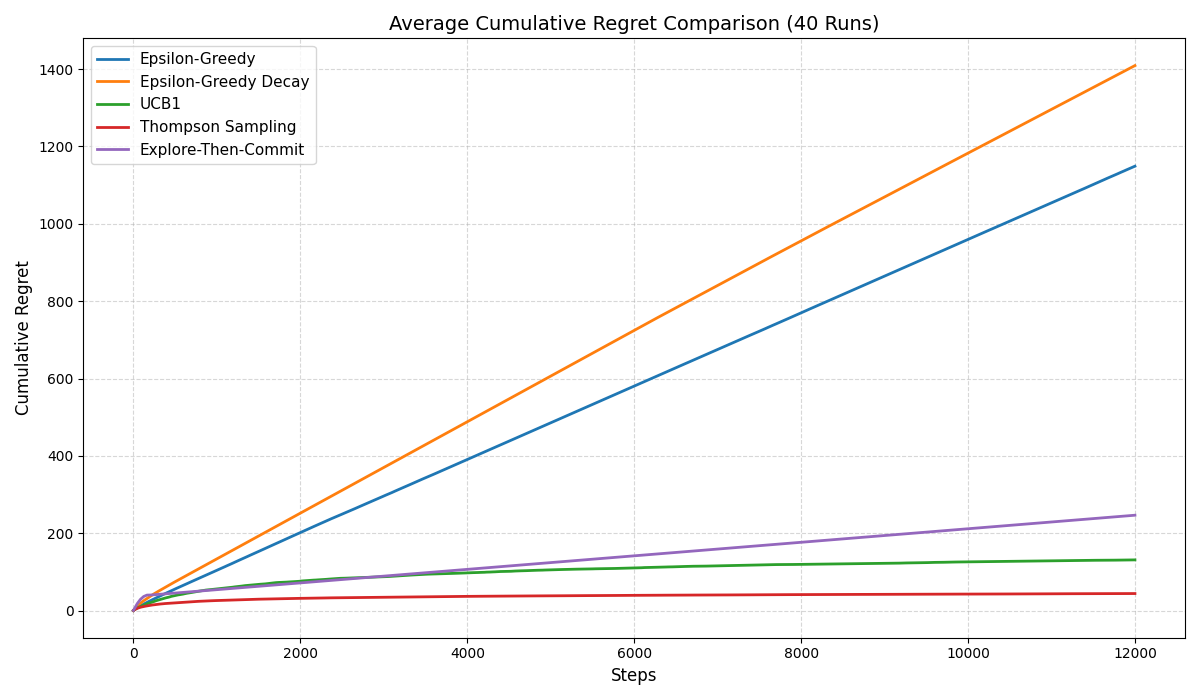

In [3]:
# import matplotlib.pyplot as plt
K = 5                                # Number of arms
means = [0.3, 0.4, 0.5, 0.6, 0.7]    # Bernoulli success probabilities for each arm
total_steps = 12000                  # Horizon (number of rounds per run)
num_runs = 40                        # Number of simulations to average over

# Hyperparameters for the algorithms
EPSILON = 0.1
EPSILON_START = 1.0
EPSILON_MIN = 0.005
DECAY_RATE = 0.99
ETC_M = 40                           # Explore-then-commit steps per arm (Total exploration = K * m)
SAMBA_ALPHA = 0.1
SAMBA_BETA = 2.0

# Run the simulations
averaged_results = run_experiment(num_runs, means, rng, total_steps, EPSILON, EPSILON_START, EPSILON_MIN, DECAY_RATE, ETC_M)
plt.figure(figsize=(12, 7))

for algo_name, avg_regret in averaged_results.items():
    plt.plot(avg_regret, label=algo_name, linewidth=2)

plt.title(f"Average Cumulative Regret Comparison ({num_runs} Runs)", fontsize=14)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Cumulative Regret", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()

# Render the plot
plt.show()

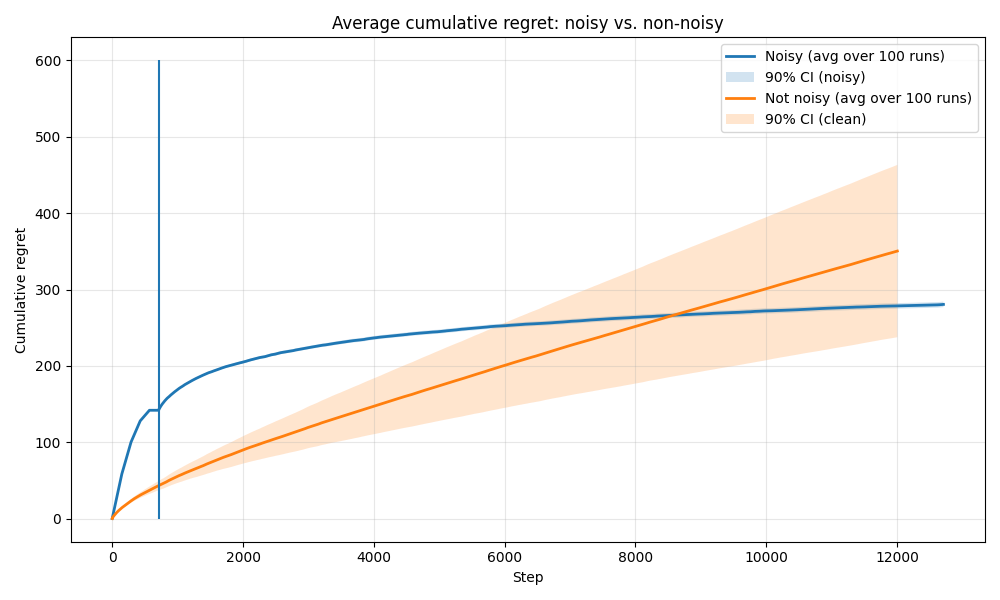

In [4]:
import numpy as np
import matplotlib.pyplot as plt

num_runs = 100
top_means = [0.4, 0.5, 0.6, 0.7, 0.8]
avg_noisy_regret, noisy_histories = run_spsamf_experiment(means, top_means, rng, True, num_runs, total_steps)
avg_clean_regret, clean_histories = run_spsamf_experiment(means, top_means, rng, False, num_runs, total_steps)

noisy_arr = np.vstack(noisy_histories)
clean_arr = np.vstack(clean_histories)

def ninety_percent_ci(arr):
    mean = arr.mean(axis=0)
    std = arr.std(axis=0, ddof=1)
    margin = 1.645 * std / np.sqrt(arr.shape[0])  # 90% CI, normal approx
    return mean, mean - margin, mean + margin

avg_noisy_regret, noisy_ci_low, noisy_ci_high = ninety_percent_ci(noisy_arr)
avg_clean_regret, clean_ci_low, clean_ci_high = ninety_percent_ci(clean_arr)

plt.figure(figsize=(10, 6))

plt.plot(avg_noisy_regret, label=f"Noisy (avg over {num_runs} runs)", linewidth=2)
plt.fill_between(
    np.arange(len(avg_noisy_regret)),
    noisy_ci_low,
    noisy_ci_high,
    alpha=0.2,
    label="90% CI (noisy)",
)

plt.plot(avg_clean_regret, label=f"Not noisy (avg over {num_runs} runs)", linewidth=2)
plt.fill_between(
    np.arange(len(avg_clean_regret)),
    clean_ci_low,
    clean_ci_high,
    alpha=0.2,
    label="90% CI (clean)",
)
plt.vlines([710], 0, 600)
plt.xlabel("Step")
plt.ylabel("Cumulative regret")
plt.title("Average cumulative regret: noisy vs. non-noisy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
means = [0.3, 0.4, 0.5, 0.6, 0.7]
top_means = [0.4, 0.5, 0.6, 0.7, 0.8]
num_runs = 20
total_steps = 1000

strategies = [
    ("Optimal", "optimal", None),
    ("Underbid", "underbid", 0.05),
    ("Overbid", "overbid", 0.05),
]

results = []
for label, strategy, amount in strategies:
    result = run_strategy_experiment(
        means=means,
        top_means=top_means,
        rng=rng,
        num_runs=num_runs,
        total_steps=total_steps,
        strategy=strategy,
        amount=amount,
        noisy=False,
    )
    results.append((label, result[0], result[1]))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for label, platform_reward, _ in results:
    plt.bar(label, platform_reward, alpha=0.8)
plt.ylabel("Average platform reward")
plt.title("Platform reward by strategy")
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
for label, _, arm_utilities in results:
    plt.plot(np.arange(len(arm_utilities)), arm_utilities, marker="o", label=label)
plt.xlabel("Arm index")
plt.ylabel("Average arm utility")
plt.title("Arm utilities by strategy")
plt.legend()
plt.tight_layout()
plt.show()
